In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [51]:
DATA_DIR = Path("../data/CMAPSSData")
IMG_DIR = Path("../images")

In [52]:
COLS = ["unit", "cycle"] + [f"op_{i}" for i in range(1, 4)] + [f"s_{i}" for i in range(1, 22)]

In [53]:
def load(name):
    return pd.read_csv(DATA_DIR / name, sep=r"\s+", header=None, names=COLS, engine="python")

In [54]:
train = load("train_FD001.txt")
test = load("test_FD001.txt")
rul_test = pd.read_csv(DATA_DIR / "RUL_FD001.txt", header=None, names=["RUL"]).squeeze("columns")

In [55]:
print("=" * 60)
print("SHAPES")
print("=" * 60)
print(f"train: {train.shape}, units: {train.unit.nunique()}")
print(f"test:  {test.shape}, units: {test.unit.nunique()}")
print(f"RUL:   {rul_test.shape}")
 
print("\n" + "=" * 60)
print("MISSING / DUPLICATES")
print("=" * 60)
print(f"train NaN total: {train.isna().sum().sum()}")
print(f"test  NaN total: {test.isna().sum().sum()}")
print(f"train duplicated rows: {train.duplicated().sum()}")
 
life_train = train.groupby("unit").cycle.max()
print("\n" + "=" * 60)
print("LIFESPAN DISTRIBUTION (train: cycles until failure)")
print("=" * 60)
print(life_train.describe().round(1).to_string())
 
last_test = test.groupby("unit").cycle.max()
true_life_test = last_test.values + rul_test.values
print("\n" + "=" * 60)
print("TRUE LIFESPAN DISTRIBUTION (test: last observed cycle + RUL)")
print("=" * 60)
print(pd.Series(true_life_test).describe().round(1).to_string())
 
print("\n" + "=" * 60)
print("OPERATIONAL SETTINGS")
print("=" * 60)
print(train[["op_1", "op_2", "op_3"]].describe().round(3).to_string())
 
print("\n" + "=" * 60)
print("SENSOR VARIABILITY (std on train)")
print("=" * 60)
sensor_cols = [f"s_{i}" for i in range(1, 22)]
stds = train[sensor_cols].std().sort_values()
print(stds.round(4).to_string())
constant_sensors = stds[stds < 1e-6].index.tolist()
print(f"\nConstant sensors (std < 1e-6): {constant_sensors}")

SHAPES
train: (20631, 26), units: 100
test:  (13096, 26), units: 100
RUL:   (100,)

MISSING / DUPLICATES
train NaN total: 0
test  NaN total: 0
train duplicated rows: 0

LIFESPAN DISTRIBUTION (train: cycles until failure)
count    100.0
mean     206.3
std       46.3
min      128.0
25%      177.0
50%      199.0
75%      229.2
max      362.0

TRUE LIFESPAN DISTRIBUTION (test: last observed cycle + RUL)
count    100.0
mean     206.5
std       44.0
min      141.0
25%      174.8
50%      199.0
75%      227.8
max      341.0

OPERATIONAL SETTINGS
            op_1       op_2     op_3
count  20631.000  20631.000  20631.0
mean      -0.000      0.000    100.0
std        0.002      0.000      0.0
min       -0.009     -0.001    100.0
25%       -0.002     -0.000    100.0
50%        0.000      0.000    100.0
75%        0.002      0.000    100.0
max        0.009      0.001    100.0

SENSOR VARIABILITY (std on train)
s_1      0.0000
s_10     0.0000
s_19     0.0000
s_18     0.0000
s_16     0.0000
s_5    

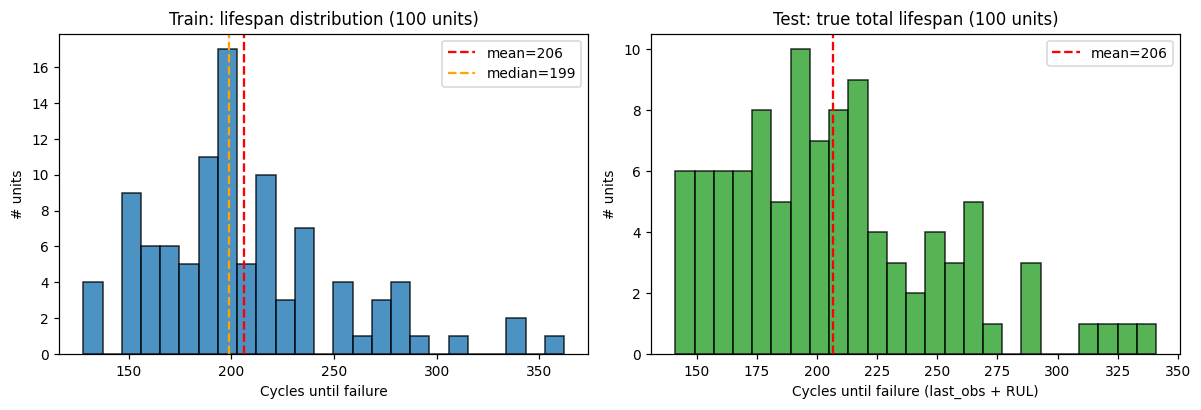

In [56]:
# --- PLOTS ---
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
 
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(life_train, bins=25, edgecolor="black", alpha=0.8)
axes[0].axvline(life_train.mean(), color="red", ls="--", label=f"mean={life_train.mean():.0f}")
axes[0].axvline(life_train.median(), color="orange", ls="--", label=f"median={life_train.median():.0f}")
axes[0].set_xlabel("Cycles until failure")
axes[0].set_ylabel("# units")
axes[0].set_title("Train: lifespan distribution (100 units)")
axes[0].legend()
 
axes[1].hist(true_life_test, bins=25, edgecolor="black", alpha=0.8, color="tab:green")
axes[1].axvline(np.mean(true_life_test), color="red", ls="--", label=f"mean={np.mean(true_life_test):.0f}")
axes[1].set_xlabel("Cycles until failure (last_obs + RUL)")
axes[1].set_ylabel("# units")
axes[1].set_title("Test: true total lifespan (100 units)")
axes[1].legend()
plt.tight_layout()
plt.savefig(IMG_DIR / "01_lifespan.png", bbox_inches="tight")
plt.show()
plt.close()

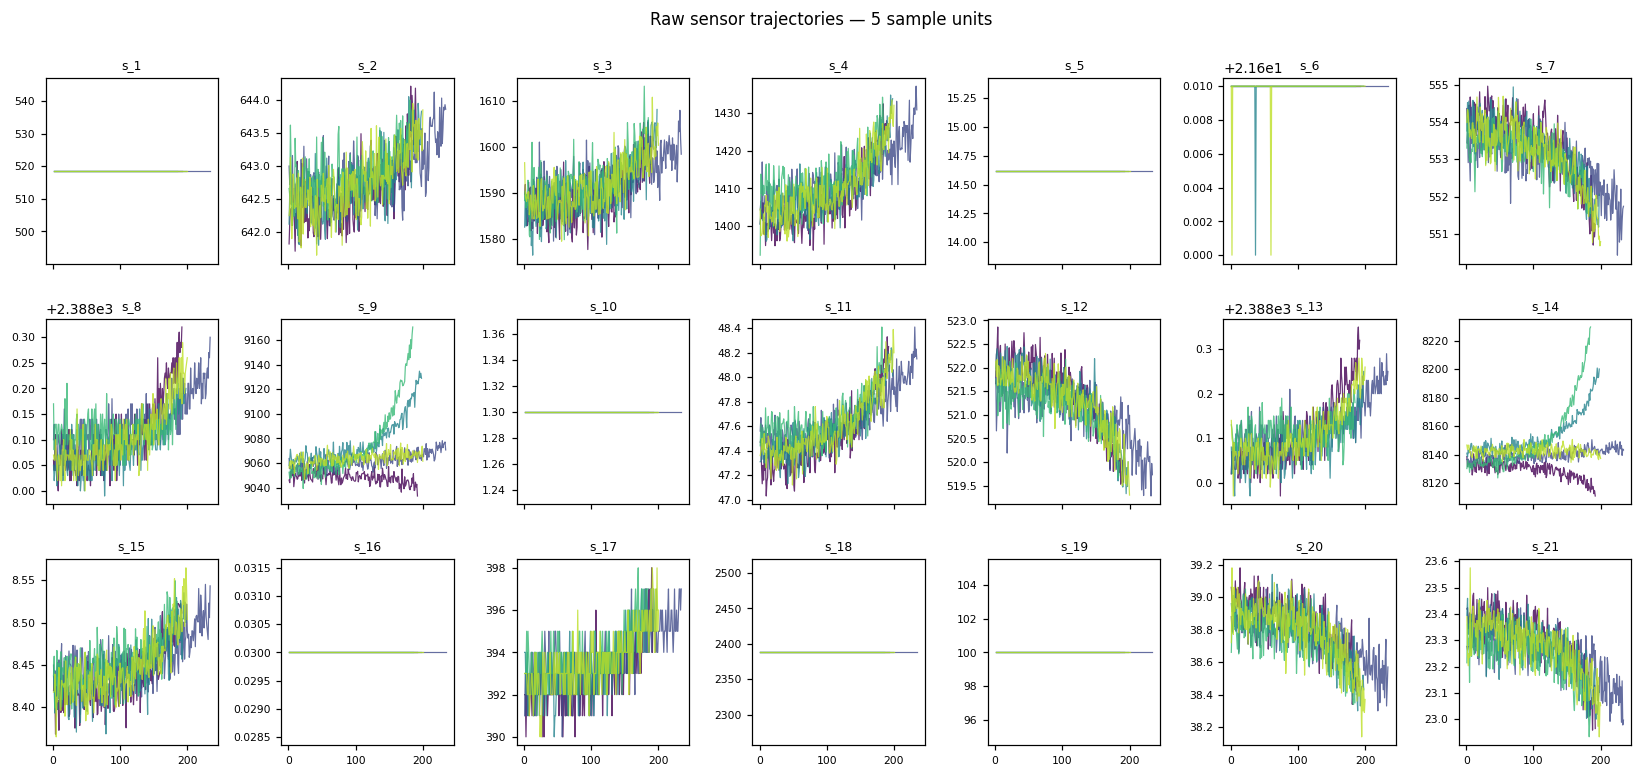

In [57]:
fig, axes = plt.subplots(3, 7, figsize=(15, 7), sharex=True)
sample_units = [1, 20, 50, 80, 100]
colors = plt.cm.viridis(np.linspace(0, 0.9, len(sample_units)))
for ax, sensor in zip(axes.flat, sensor_cols):
    for u, c in zip(sample_units, colors):
        sub = train[train.unit == u]
        ax.plot(sub.cycle, sub[sensor], color=c, alpha=0.8, lw=0.8)
    ax.set_title(sensor, fontsize=8)
    ax.tick_params(labelsize=7)
fig.suptitle("Raw sensor trajectories — 5 sample units", y=1.00)
plt.tight_layout()
plt.savefig(IMG_DIR / "02_sensors_raw.png", bbox_inches="tight")
plt.show()
plt.close()

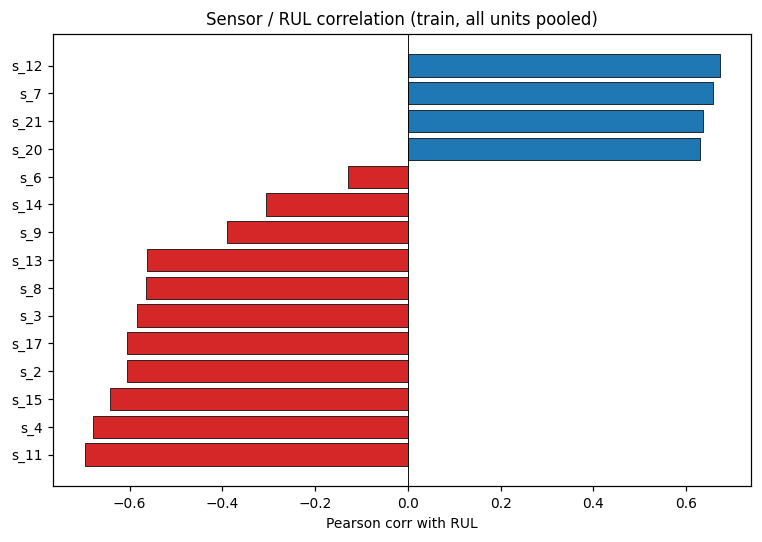

In [58]:
train_rul = train.copy()
train_rul["RUL"] = train_rul.groupby("unit").cycle.transform("max") - train_rul.cycle
informative = stds[stds > 1e-6].index.tolist()
corrs = train_rul[informative + ["RUL"]].corr()["RUL"].drop("RUL").sort_values()
 
fig, ax = plt.subplots(figsize=(7, 5))
colors_b = ["tab:red" if v < 0 else "tab:blue" for v in corrs.values]
ax.barh(corrs.index, corrs.values, color=colors_b, edgecolor="black", lw=0.5)
ax.axvline(0, color="black", lw=0.6)
ax.set_xlabel("Pearson corr with RUL")
ax.set_title("Sensor / RUL correlation (train, all units pooled)")
plt.tight_layout()
plt.savefig(IMG_DIR / "03_corr_rul.png", bbox_inches="tight")
plt.show()
plt.close()

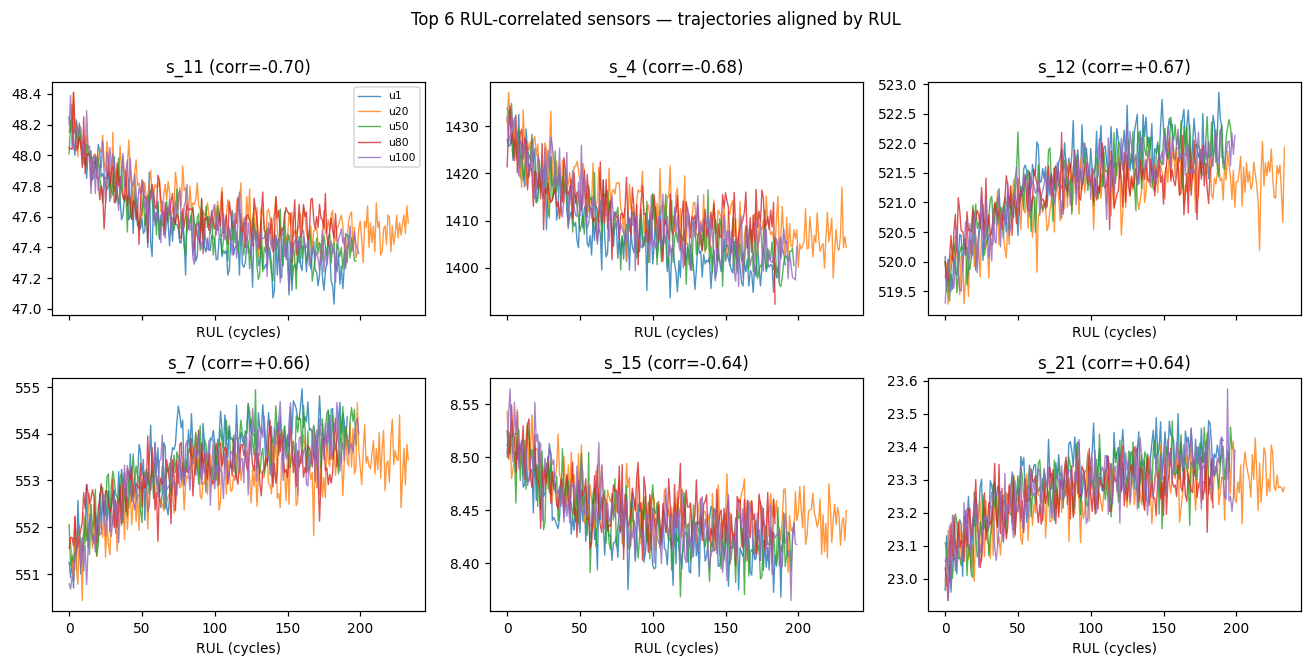

In [60]:
top = corrs.abs().sort_values(ascending=False).head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
for ax, sensor in zip(axes.flat, top):
    for u in sample_units:
        sub = train_rul[train_rul.unit == u].sort_values("RUL", ascending=False)
        ax.plot(sub["RUL"].values[::-1], sub[sensor].values[::-1], alpha=0.8, lw=0.9, label=f"u{u}")
    ax.invert_xaxis()
    ax.set_title(f"{sensor} (corr={corrs[sensor]:+.2f})")
    ax.set_xlabel("RUL (cycles)")
axes.flat[0].legend(fontsize=7, loc="best")
fig.suptitle("Top 6 RUL-correlated sensors — trajectories aligned by RUL", y=1.00)
plt.tight_layout()
plt.savefig(IMG_DIR / "04_top_sensors_vs_rul.png", bbox_inches="tight")
plt.show()
plt.close()